# 03 — SRGAN training

Train a 4× super-resolution GAN using only the persisted training manifest. Inputs are 32×32 and real targets are 128×128. Both use the separately documented SRGAN range `[-1, 1]`. The reserved test manifest is never loaded here.

## Local setup

Run this notebook from the local repository with the project virtual environment selected as the Jupyter kernel. Checkpoints and fixed progress samples are written locally every five epochs. Rerunning **Run all** selects the newest complete checkpoint automatically and skips corrupt or incomplete files.

In [1]:
import sys
from pathlib import Path

start_directory = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        candidate
        for candidate in (start_directory, *start_directory.parents)
        if (candidate / 'pyproject.toml').is_file()
        and (candidate / 'src' / 'applied_ai_midterm').is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    codex_workspace = Path.home() / 'Documents' / 'Codex'
    if codex_workspace.is_dir():
        PROJECT_ROOT = next(
            (
                config_file.parent
                for config_file in codex_workspace.rglob('pyproject.toml')
                if config_file.parent.name == 'MLawson-Applied-AI-Midterm'
                and (config_file.parent / 'src' / 'applied_ai_midterm').is_dir()
            ),
            None,
        )
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        'Open this notebook from inside the MLawson-Applied-AI-Midterm repository.'
    )
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
print(f'Local project root: {PROJECT_ROOT}')
print(f'Python kernel: {sys.executable}')

Local project root: <PROJECT_ROOT>
Python kernel: <PROJECT_ROOT>/.venv/bin/python


In [2]:
import json
from dataclasses import asdict

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR

from applied_ai_midterm.config import load_config
from applied_ai_midterm.srgan import Discriminator, Generator, GeneratorLoss
from applied_ai_midterm.srgan_data import create_srgan_dataloaders
from applied_ai_midterm.srgan_training import (
    fit_srgan,
    peak_signal_to_noise_ratio,
    structural_similarity,
)
from applied_ai_midterm.training import seed_everything, select_device
from applied_ai_midterm.transforms import denormalize_srgan

## Reproducible paths and data

A fixed, deterministic validation subset is derived only from `train.csv`. Its first samples are saved into each checkpoint and progress file for consistent visual comparisons.

In [3]:
config = load_config(PROJECT_ROOT / 'configs' / 'config.yaml')
seed_everything(config.random_seed)
device = select_device()

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
CHECKPOINT_DIR = PROJECT_ROOT / 'artifacts' / 'checkpoints' / 'srgan'

TRAIN_MANIFEST = PROJECT_ROOT / 'data' / 'splits' / 'train.csv'
VALIDATION_RATIO = 0.20
print(f'Device: {device}')
if device.type == 'cpu':
    print('Warning: 150 SRGAN epochs on CPU will be very slow.')
print(f'Checkpoints: {CHECKPOINT_DIR}')
if not RAW_DIR.is_dir():
    raise FileNotFoundError(
        f'Raw dataset missing at {RAW_DIR}. Run notebook 01 setup, then Run all again.'
    )
if not TRAIN_MANIFEST.is_file():
    raise FileNotFoundError(
        f'Training manifest missing at {TRAIN_MANIFEST}. Run notebook 01 first.'
    )

Device: mps
Checkpoints: <PROJECT_ROOT>/artifacts/checkpoints/srgan


In [4]:
loaders = create_srgan_dataloaders(
    TRAIN_MANIFEST,
    RAW_DIR,
    low_resolution_size=config.low_resolution_size,
    high_resolution_size=config.high_resolution_size,
    batch_size=config.srgan_batch_size,
    validation_ratio=VALIDATION_RATIO,
    random_seed=config.random_seed,
    num_workers=config.num_workers,
    fixed_sample_count=4,
)
print(f'Training examples: {loaders.train_size:,}')
print(f'Validation examples: {loaders.validation_size:,}')
print(f'Class mapping: {loaders.class_mapping}')

Training examples: 13,960
Validation examples: 3,491
Class mapping: {'cats': 0, 'dogs': 1}


## Models, losses, and optimizers

The generator objective combines L1 pixel reconstruction and adversarial `BCEWithLogitsLoss`. Optional frozen VGG19 perceptual loss can be enabled by setting `PERCEPTUAL_WEIGHT` above zero; doing so downloads ImageNet VGG weights once. The default avoids that additional memory and runtime cost.

In [5]:
GENERATOR_LEARNING_RATE = 1e-4
DISCRIMINATOR_LEARNING_RATE = 1e-4
PIXEL_WEIGHT = 1.0
ADVERSARIAL_WEIGHT = 1e-3
PERCEPTUAL_WEIGHT = 0.0
RESIDUAL_BLOCKS = 16

generator = Generator(residual_blocks=RESIDUAL_BLOCKS)
discriminator = Discriminator()
generator_loss = GeneratorLoss(
    pixel_weight=PIXEL_WEIGHT,
    adversarial_weight=ADVERSARIAL_WEIGHT,
    perceptual_weight=PERCEPTUAL_WEIGHT,
)
generator_optimizer = Adam(
    generator.parameters(), lr=GENERATOR_LEARNING_RATE, betas=(0.9, 0.999)
)
discriminator_optimizer = Adam(
    discriminator.parameters(),
    lr=DISCRIMINATOR_LEARNING_RATE,
    betas=(0.9, 0.999),
)
generator_scheduler = StepLR(generator_optimizer, step_size=50, gamma=0.5)
discriminator_scheduler = StepLR(
    discriminator_optimizer, step_size=50, gamma=0.5
)

## Train or automatically resume for 150 epochs

This is the long-running local training cell. A complete restartable checkpoint and fixed progress sample are written after epochs 5, 10, 15, and so on through 150.

In [6]:
run_configuration = {
    **asdict(config),
    'generator': 'SRGAN Generator',
    'discriminator': 'SRGAN Discriminator',
    'residual_blocks': RESIDUAL_BLOCKS,
    'generator_learning_rate': GENERATOR_LEARNING_RATE,
    'discriminator_learning_rate': DISCRIMINATOR_LEARNING_RATE,
    'pixel_weight': PIXEL_WEIGHT,
    'adversarial_weight': ADVERSARIAL_WEIGHT,
    'perceptual_weight': PERCEPTUAL_WEIGHT,
    'validation_ratio': VALIDATION_RATIO,
}
history = fit_srgan(
    generator,
    discriminator,
    loaders.train,
    loaders.validation,
    generator_optimizer,
    discriminator_optimizer,
    generator_loss,
    epochs=config.srgan_epochs,
    checkpoint_interval=config.checkpoint_interval,
    device=device,
    checkpoint_dir=CHECKPOINT_DIR,
    class_mapping=loaders.class_mapping,
    random_seed=config.random_seed,
    configuration=run_configuration,
    fixed_low_resolution=loaders.fixed_low_resolution,
    fixed_high_resolution=loaders.fixed_high_resolution,
    generator_scheduler=generator_scheduler,
    discriminator_scheduler=discriminator_scheduler,
    automatic_resume=True,
)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
history_path = CHECKPOINT_DIR / 'srgan_history.json'
history_path.write_text(json.dumps(history, indent=2), encoding='utf-8')
print(f'History saved: {history_path}')
print(f'Checkpoint directory: {CHECKPOINT_DIR}')

Epoch 001/150: G=0.1048, D=0.1393, PSNR=24.67, SSIM=0.8086


Epoch 002/150: G=0.0754, D=0.0488, PSNR=25.40, SSIM=0.8298


Epoch 003/150: G=0.0686, D=0.0070, PSNR=25.67, SSIM=0.8390


Epoch 004/150: G=0.0650, D=0.0075, PSNR=25.83, SSIM=0.8440


Epoch 005/150: G=0.0627, D=0.0011, PSNR=25.92, SSIM=0.8478


...

Epoch 146/150: G=0.0457, D=0.0000, PSNR=27.26, SSIM=0.8786


Epoch 147/150: G=0.0458, D=0.0000, PSNR=27.29, SSIM=0.8787


Epoch 148/150: G=0.0457, D=0.0000, PSNR=27.23, SSIM=0.8783


Epoch 149/150: G=0.0460, D=0.0009, PSNR=27.25, SSIM=0.8781


Epoch 150/150: G=0.0466, D=0.0000, PSNR=27.21, SSIM=0.8778
History saved: <PROJECT_ROOT>/artifacts/checkpoints/srgan/srgan_history.json
Checkpoint directory: <PROJECT_ROOT>/artifacts/checkpoints/srgan


## Loss and validation-quality curves

Final validation PSNR: 27.21 dB
Final validation SSIM: 0.8778


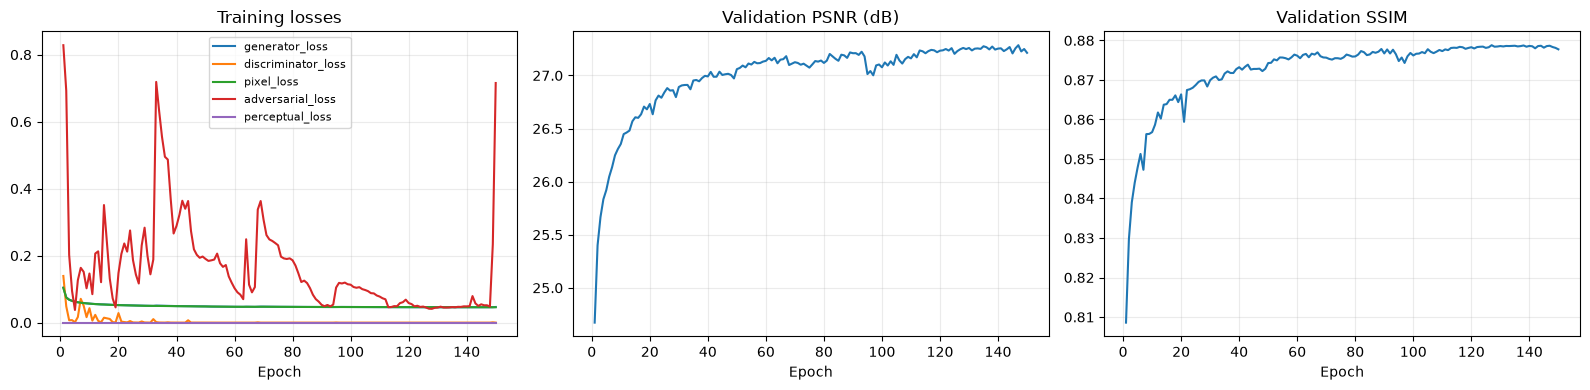

In [7]:
epochs = [int(row['epoch']) for row in history]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for name in (
    'generator_loss',
    'discriminator_loss',
    'pixel_loss',
    'adversarial_loss',
    'perceptual_loss',
):
    axes[0].plot(epochs, [row[name] for row in history], label=name)
axes[0].set_title('Training losses')
axes[0].legend(fontsize=8)
axes[1].plot(epochs, [row['validation_psnr'] for row in history])
axes[1].set_title('Validation PSNR (dB)')
axes[2].plot(epochs, [row['validation_ssim'] for row in history])
axes[2].set_title('Validation SSIM')
for axis in axes:
    axis.set_xlabel('Epoch')
    axis.grid(alpha=0.25)
plt.tight_layout()
final_metrics = history[-1]
print(f"Final validation PSNR: {final_metrics['validation_psnr']:.2f} dB")
print(f"Final validation SSIM: {final_metrics['validation_ssim']:.4f}")

## Fixed 32×32, bicubic, generated, and real comparisons

Fixed-sample PSNR: 28.89 dB
Fixed-sample SSIM: 0.9050


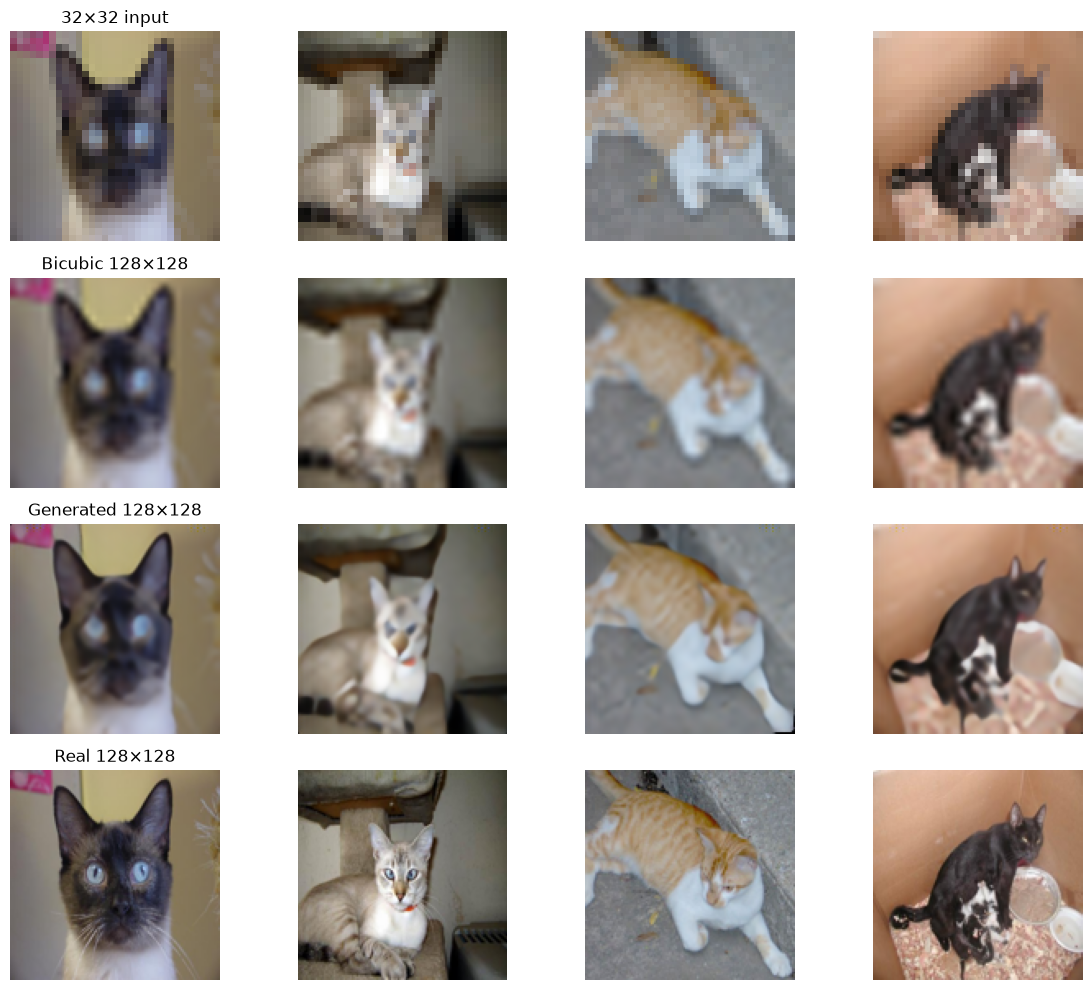

In [8]:
generator.eval()
fixed_low = loaders.fixed_low_resolution.to(device)
fixed_high = loaders.fixed_high_resolution.to(device)
with torch.no_grad():
    fixed_generated = generator(fixed_low)

low_display = denormalize_srgan(fixed_low).cpu()
generated_display = denormalize_srgan(fixed_generated).cpu()
high_display = denormalize_srgan(fixed_high).cpu()
bicubic_display = F.interpolate(
    low_display,
    size=(config.high_resolution_size, config.high_resolution_size),
    mode='bicubic',
    align_corners=False,
).clamp(0, 1)

fig, axes = plt.subplots(4, len(low_display), figsize=(12, 10))
rows = (
    ('32×32 input', low_display),
    ('Bicubic 128×128', bicubic_display),
    ('Generated 128×128', generated_display),
    ('Real 128×128', high_display),
)
for row_index, (title, images) in enumerate(rows):
    for column, image in enumerate(images):
        axes[row_index, column].imshow(image.permute(1, 2, 0))
        axes[row_index, column].axis('off')
        if column == 0:
            axes[row_index, column].set_title(title)
plt.tight_layout()

print(
    'Fixed-sample PSNR:',
    f'{peak_signal_to_noise_ratio(fixed_generated, fixed_high):.2f} dB',
)
print(
    'Fixed-sample SSIM:',
    f'{structural_similarity(fixed_generated, fixed_high):.4f}',
)